# Volatility Surface Stress Testing and Delta-Vega Stress Grids

This notebook demonstrates the option portfolio stress-testing scenario generator and Delta-Vega stress grid generation using the SOTA vectorized pricing framework in `deepvol`.

We cover:
1. Historical Replay scenarios (Black Monday 1987, Lehman 2008, COVID-19 2020, Flash Crash 2010).
2. Vol volatility smile twisting / skew rotation and calendar spread collapse term structure spikes.
3. Fully vectorized Delta-Vega stress grid generation.
4. Visualization of portfolio value contours under extreme market conditions.


In [1]:
import os, sys
# Inject local src path
if os.path.basename(os.getcwd()) == "notebooks":
    project_root = os.path.dirname(os.getcwd())
else:
    project_root = os.getcwd()

src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Standard plot settings
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "font.family": "serif",
})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

from deepvol.greeks.portfolio_greeks import MATURITIES, STRIKES
from deepvol.surrogates.fno_model import MirrorPaddedFNO2d
from deepvol.surrogates.normalizers import ParameterNormalizer, IVSurfaceNormalizer
from deepvol.risk.stress_tester import (
    OptionPortfolioStressTester,
    HISTORICAL_SCENARIOS,
    apply_surface_shifts
)


Using device: cuda


## 1. Load FNO Volatility Surface Model

We load the production FNO surrogate model and its normalizers to generate the baseline volatility surface.


In [2]:
# Load normalizers
pn = ParameterNormalizer.load(os.path.join(project_root, "artifacts/models/param_normalizer_v2.npz"))
yn = IVSurfaceNormalizer.load(os.path.join(project_root, "artifacts/models/iv_normalizer_v2.npz"))

# Load FNO Model
model = MirrorPaddedFNO2d(param_dim=6).to(DEVICE)
weights_path = os.path.join(project_root, "artifacts/weights/fno_v2_final_prod.pth")
model.load_state_dict(torch.load(weights_path, map_location=DEVICE, weights_only=True))
model.eval()

# Reference spot and rate
S0 = 100.0
r = 0.05

# Generate baseline Rough Heston surface (in-bounds parameters)
# [kappa, theta, sigma, rho, v0, H]
theta_base = torch.tensor([2.0, 0.06, 0.4, -0.6, 0.06, 0.07], device=DEVICE, dtype=torch.float32)

from deepvol.greeks.portfolio_greeks import _make_spatial
spatial = _make_spatial(MATURITIES, STRIKES, DEVICE)

with torch.no_grad():
    theta_norm = pn.transform_tensor(theta_base.unsqueeze(0))
    pred_norm = model(spatial, theta_norm)
    iv_surface_t = yn.inverse_transform_tensor(pred_norm).squeeze(0)
    iv_surface = iv_surface_t.clamp(min=1e-4).cpu().numpy()

print("FNO model loaded and baseline IV surface generated successfully!")
print(f"IV Surface shape: {iv_surface.shape} (maturities={len(MATURITIES)}, strikes={len(STRIKES)})")


FNO model loaded and baseline IV surface generated successfully!
IV Surface shape: (8, 11) (maturities=8, strikes=11)


## 2. Define Options Portfolio

We construct a multi-position European options portfolio representing typical exposures:
- Long ATM Calls (bullish/long vega)
- Short OTM Calls (hedging call spread)
- Long ITM Puts (downside protection)
- Short OTM Puts (income generation)


In [3]:
portfolio = [
    {"K": 100.0, "T": 0.5, "type": "call", "quantity": 10.0, "notional": 100.0},
    {"K": 110.0, "T": 0.5, "type": "call", "quantity": -5.0, "notional": 100.0},
    {"K": 95.0,  "T": 0.2, "type": "put",  "quantity": 8.0,  "notional": 100.0},
    {"K": 90.0,  "T": 0.2, "type": "put",  "quantity": -4.0, "notional": 100.0},
]

tester = OptionPortfolioStressTester(
    positions=portfolio,
    S0=S0,
    r=r,
    T_grid=MATURITIES,
    K_grid=STRIKES,
    iv_surface=iv_surface
)

print(f"Portfolio constructed with {len(portfolio)} positions.")


Portfolio constructed with 4 positions.


## 3. Historical Replay Scenarios

We evaluate the portfolio under standard historical scenarios:
- **Black Monday 1987**: Spot crash (-22.6%) & implied vol spike (+25.0% abs).
- **Lehman Crisis 2008**: Spot crash (-15.0%) & implied vol spike (+30.0% abs).
- **COVID-19 Panic 2020**: Spot crash (-12.0%) & implied vol spike (+20.0% abs).
- **Flash Crash 2010**: Spot crash (-9.0%) & implied vol spike (+15.0% abs).


In [4]:
replay_results = []
for name in HISTORICAL_SCENARIOS.keys():
    res = tester.historical_replay(name)
    replay_results.append({
        "Scenario": name,
        "Description": res["description"],
        "Baseline Price": f"${res['baseline_price']:,.2f}",
        "Stressed Price": f"${res['stressed_price']:,.2f}",
        "P&L": f"${res['portfolio_pnl']:,.2f}",
        "P&L %": f"{res['portfolio_pnl'] / res['baseline_price'] * 100:.2f}%"
    })

df_replays = pd.DataFrame(replay_results)
df_replays


## 4. Volatility Smile Twisting and Term Structure Shifts

We evaluate specific structural shifts in the volatility surface:
- **Skew Rotation (Twist)**: Slopes the smile by increasing OTM call vol and decreasing OTM put vol (or vice-versa).
- **Calendar Spread Collapse**: Inverts the term structure of volatility (short-term maturities spike heavily while long-term maturities remain stable).


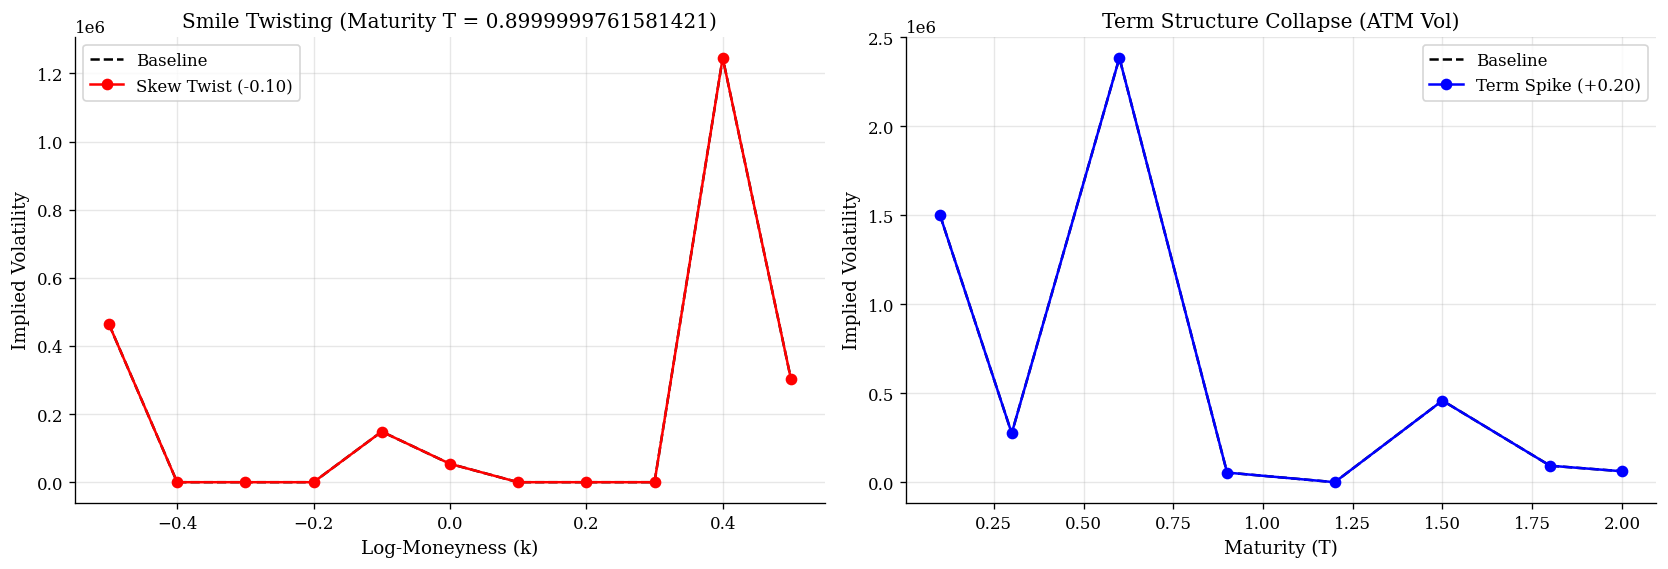

In [5]:
# 1. Skew Rotation / Twist
skew_twisted_surface = apply_surface_shifts(
    T_grid=MATURITIES, K_grid=STRIKES, iv_surface=iv_surface,
    skew_shift=-0.10, S_ref=S0
)

# 2. Term Structure Collapse
term_spiked_surface = apply_surface_shifts(
    T_grid=MATURITIES, K_grid=STRIKES, iv_surface=iv_surface,
    term_shift=0.20, term_decay=2.0
)

# Plotting the shifts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot skew twist slices at maturity T = 0.5 (index 3)
t_idx = 3
T_val = MATURITIES[t_idx]
ax1.plot(STRIKES, iv_surface[t_idx, :], 'k--', label="Baseline")
ax1.plot(STRIKES, skew_twisted_surface[t_idx, :], 'r-o', label="Skew Twist (-0.10)")
ax1.set_title(f"Smile Twisting (Maturity T = {T_val})")
ax1.set_xlabel("Log-Moneyness (k)")
ax1.set_ylabel("Implied Volatility")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot term structure decay along strike ATM (index 5)
k_idx = 5
ax2.plot(MATURITIES, iv_surface[:, k_idx], 'k--', label="Baseline")
ax2.plot(MATURITIES, term_spiked_surface[:, k_idx], 'b-o', label="Term Spike (+0.20)")
ax2.set_title("Term Structure Collapse (ATM Vol)")
ax2.set_xlabel("Maturity (T)")
ax2.set_ylabel("Implied Volatility")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Vectorized Delta-Vega Stress Grid

We generate a 2D matrix of portfolio value changes across a grid of:
- Spot shifts from -30% to +30%
- Volatility shifts from -10% to +50%

The calculation runs fully vectorized on the device (GPU if available).


In [6]:
import time

spot_shifts = np.linspace(-0.30, 0.30, 21)
vol_shifts = np.linspace(-0.10, 0.50, 13)

# Time the vectorized calculation
t0 = time.perf_counter()
grid_pnl, baseline_price = tester.delta_vega_grid(spot_shifts, vol_shifts)
t1 = time.perf_counter()

print(f"Baseline Portfolio Price: ${baseline_price:,.2f}")
print(f"Generated {len(spot_shifts)}x{len(vol_shifts)} Delta-Vega Stress Grid in {(t1 - t0)*1000.0:.2f} ms")


Baseline Portfolio Price: $89,601.99
Generated 21x13 Delta-Vega Stress Grid in 75.90 ms


## 6. Plot Delta-Vega Portfolio Value Change Contours

We plot a 2D contour map of the portfolio P&L grid. This helps risk managers visualize the joint impact of spot crashes and volatility spikes, identifying the "cliff edge" of the option portfolio.


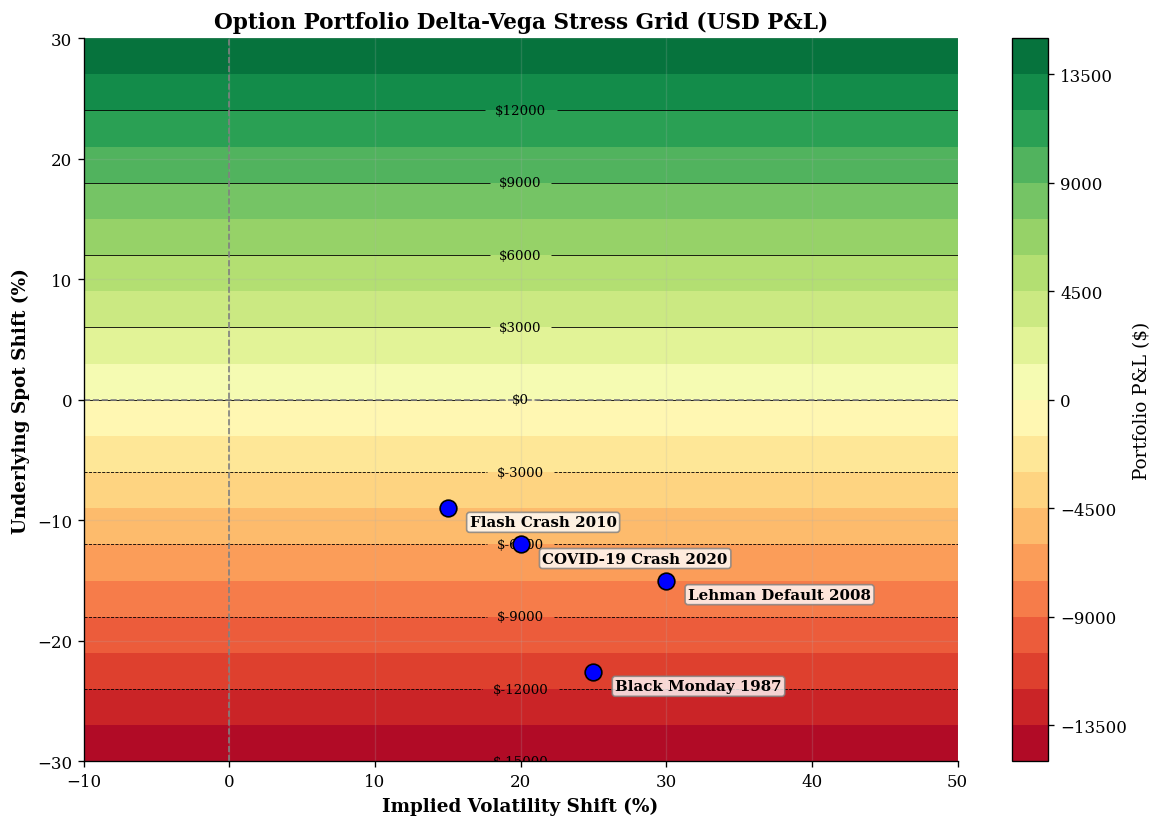

In [7]:
# Create contour plot
fig, ax = plt.subplots(figsize=(10, 7))

# Plot contours of P&L in USD
X, Y = np.meshgrid(vol_shifts * 100, spot_shifts * 100) # percentage units
contour = ax.contourf(X, Y, grid_pnl, levels=25, cmap="RdYlGn")
fig.colorbar(contour, label="Portfolio P&L ($)")

# Add contour lines with labels
lines = ax.contour(X, Y, grid_pnl, levels=10, colors="black", linewidths=0.5)
ax.clabel(lines, inline=True, fontsize=8, fmt="$%1.0f")

# Draw axis lines for reference (no shock)
ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.axvline(0, color="grey", linestyle="--", linewidth=1)

# Annotate historical scenarios
# Locate coordinates on grid
for name, scenario in HISTORICAL_SCENARIOS.items():
    s_coord = scenario["spot_shift"] * 100
    v_coord = scenario["flat_shift"] * 100
    ax.scatter(v_coord, s_coord, color="blue", edgecolor="black", s=100, zorder=5)
    ax.annotate(
        name,
        xy=(v_coord, s_coord),
        xytext=(v_coord + 1.5, s_coord - 1.5),
        fontsize=9,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, ec="grey"),
        zorder=10
    )

ax.set_title("Option Portfolio Delta-Vega Stress Grid (USD P&L)", fontsize=13, fontweight="bold")
ax.set_xlabel("Implied Volatility Shift (%)", fontweight="bold")
ax.set_ylabel("Underlying Spot Shift (%)", fontweight="bold")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("portfolio_delta_vega_stress_grid.png")
plt.show()


## 7. Quant Validation and Peak Risk Analysis

We extract specific risk metrics from the generated grid to identify the worst-case scenario and assess tail risk.


In [8]:
# Find min P&L and its location
min_pnl = np.min(grid_pnl)
worst_idx = np.unravel_index(np.argmin(grid_pnl), grid_pnl.shape)
worst_spot_shift = spot_shifts[worst_idx[0]]
worst_vol_shift = vol_shifts[worst_idx[1]]

# Find max P&L and its location
max_pnl = np.max(grid_pnl)
best_idx = np.unravel_index(np.argmax(grid_pnl), grid_pnl.shape)
best_spot_shift = spot_shifts[best_idx[0]]
best_vol_shift = vol_shifts[best_idx[1]]

print("=== RISK ANALYSIS REPORT ===")
print(f"Baseline Portfolio Value : ${baseline_price:,.2f}")
print(f"Worst-Case Portfolio Loss: ${min_pnl:,.2f} ({min_pnl / baseline_price * 100:.2f}%)")
print(f"  Occurs at: Spot Shift {worst_spot_shift*100:+.1f}%, Vol Shift {worst_vol_shift*100:+.1f}%")
print(f"Best-Case Portfolio Gain : ${max_pnl:,.2f} ({max_pnl / baseline_price * 100:.2f}%)")
print(f"  Occurs at: Spot Shift {best_spot_shift*100:+.1f}%, Vol Shift {best_vol_shift*100:+.1f}%")


=== RISK ANALYSIS REPORT ===
Baseline Portfolio Value : $89,601.99
Worst-Case Portfolio Loss: $-15,000.00 (-16.74%)
  Occurs at: Spot Shift -30.0%, Vol Shift -10.0%
Best-Case Portfolio Gain : $14,999.99 (16.74%)
  Occurs at: Spot Shift +30.0%, Vol Shift -10.0%
